# Univariate Exploratory Data Analysis (EDA)

In this notebook, we will perform univariate exploratory data analysis (EDA) on the dataset. Univariate EDA is the process of analyzing and summarizing the distribution of a single variable. This can help us understand the central tendency, variability, and shape of the data for that variable. We will use various visualization techniques such as histograms, box plots, and density plots to explore the distribution of the target variable, which is the sale price of the houses. We will also calculate summary statistics such as mean, median, mode, standard deviation, and interquartile range to further understand the distribution of the sale prices. This analysis will provide insights into the characteristics of the target variable and help us identify any potential outliers or skewness in the data.

# Setting up the scene

First, we will import the necessary libraries and load the dataset. We will also display the first few rows of the dataset to get an overview of the data.

In [13]:
import pandas as pd

# Load the dataset
train_data = pd.read_csv('../myData/train.csv')

# Display the first few rows of the dataset
train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Let's see how many rows and columns the dataset has.

In [ ]:
# Display the shape of the dataset
train_data.shape

(1460, 81)

We have 1460 rows and 81 columns in the training dataset.

Now, let's see if we have missing values or duplicates in the dataset.

In [15]:
# Get the number of missing values in each column
na_counts = train_data.isna().sum()

# Calculate the percentage of missing values for each column
na_counts = na_counts[na_counts > 0]

# Display the columns with missing values and their counts
na_percentages = (na_counts / len(train_data)) * 100

na_summary = na_counts.to_frame('Count') \
    .join(na_percentages.to_frame('Percentage'), lsuffix=' Count', rsuffix='Percentage') \
    .sort_values(by='Count', ascending=False)
print("\nSummary of columns with missing values:")
print(na_summary)


Summary of columns with missing values:
              Count  Percentage
PoolQC         1453   99.520548
MiscFeature    1406   96.301370
Alley          1369   93.767123
Fence          1179   80.753425
MasVnrType      872   59.726027
FireplaceQu     690   47.260274
LotFrontage     259   17.739726
GarageType       81    5.547945
GarageYrBlt      81    5.547945
GarageFinish     81    5.547945
GarageQual       81    5.547945
GarageCond       81    5.547945
BsmtFinType2     38    2.602740
BsmtExposure     38    2.602740
BsmtFinType1     37    2.534247
BsmtCond         37    2.534247
BsmtQual         37    2.534247
MasVnrArea        8    0.547945
Electrical        1    0.068493


As we can see, the columns with the most missing values are 'PoolQC', 'MiscFeature', 'Alley' and 'Fence'. We will drop these columns later in the data cleaning section.

Let's also check for duplicates in the dataset.

In [ ]:
train_data.duplicated().sum()

np.int64(0)

There are no duplicate rows in the dataset, which is good news for our analysis.

## Target Variable: SalePrice 

The sale price of the houses is our target variable, and it is a continuous variable. Let's start by looking at the summary statistics for the sale price.

In [17]:
train_data['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Let's also visualize the distribution of the sale prices using a histogram and a box plot.

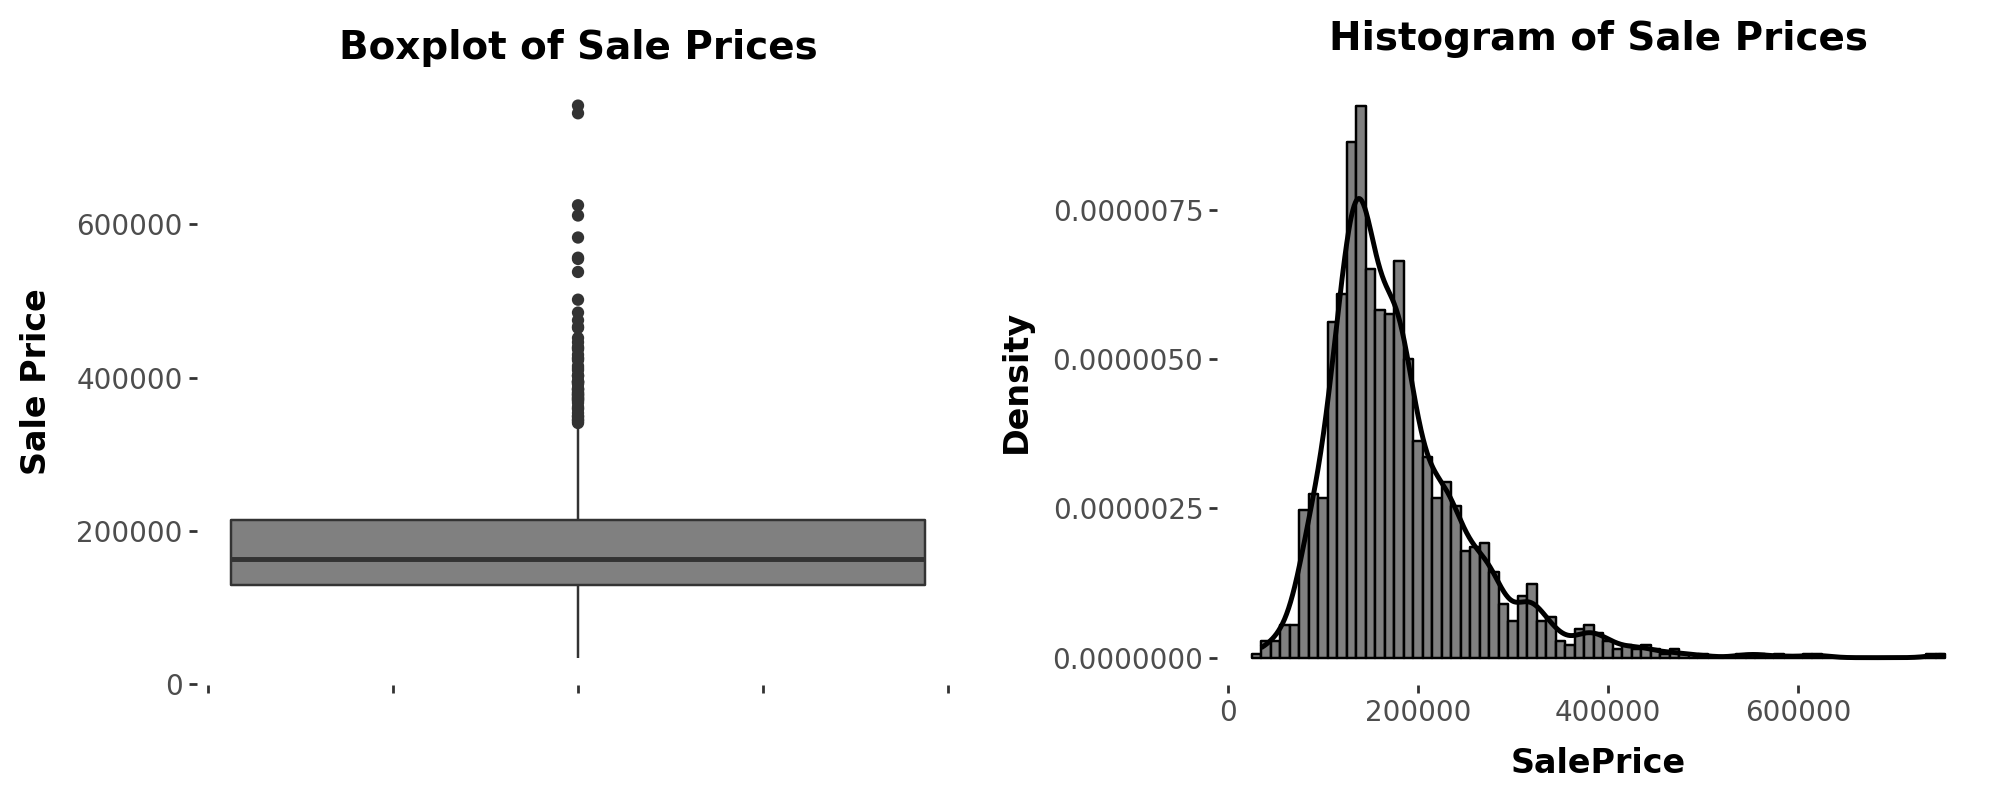

In [ ]:
from plotnine import *

# Report theme for all plots 
report_theme = theme(panel_background=element_blank(),
                     panel_grid=element_blank(),
                     axis_title=element_text(size=12, weight='bold'),
                     axis_text=element_text(size=10),
                     plot_title=element_text(size=14, weight='bold', ha='center'))

# Create a histogram of the target variable 'SalePrice'
saleprice_hist = ggplot(train_data, aes(x='SalePrice')) + \
    geom_histogram(aes(y=after_stat("density")), fill='grey', binwidth=10000, color='black') + \
    geom_density(size = 1) + \
    report_theme +  theme(figure_size=(10, 4)) + \
    labs(title='Histogram of Sale Prices', x='SalePrice', y='Density')

# Create a box plot of the target variable 'SalePrice'
saleprice_boxplot = ggplot(train_data, aes(y='SalePrice')) + \
    geom_boxplot(fill = 'grey') + \
    labs(title='Boxplot of Sale Prices', y='Sale Price') \
    + report_theme + theme(axis_text_x= element_blank())

(saleprice_boxplot | saleprice_hist) 

The salePrice of the houses has a mean of approximately 181,000 dollars, a median of 163,000 dollars, and a standard deviation of 79,442.5 dollars. The minimum sale price is 34,900 dollars, while the maximum sale price is 755,000 dollars. As we can see from the plot, the distribution of sale prices is right-skewed, with a long tail on the right side. This indicates that there are some houses with very high sale prices that are pulling the mean to the right. The median is lower than the mean, which also suggests that the distribution is skewed.